# 03 — Exploratory Data Analysis (EDA)

## Objective
Understand what behavioral patterns, driver characteristics,
and temporal trajectories most strongly predict driver churn —
building the analytical foundation for feature engineering.

## The Core EDA Question
Not: "What is this driver's average ride count?"
But: "Is this driver's ride count going UP or DOWN?"

Trajectory matters more than current value.
A driver doing 20 rides/week who was doing 35 last month
is more at risk than a driver doing 20 rides/week who was
doing 15 last month — even though both show 20 rides today.

## Business Questions We Answer
1. Which driver profile characteristics predict churn?
2. How does weekly ride volume diverge between churned
   and retained drivers over 16 weeks?
3. What is the pre-churn behavioral signature?
   (the weeks before going silent)
4. Do earnings trajectories predict churn better than
   ride count trajectories?
5. Does cancellation rate rise before churn?
6. Do support tickets predict churn and when?
7. Does incentive engagement change before churn?
8. What is the optimal "last active week" distribution?
9. Which combinations of signals are most predictive?
10. What features should Feature Engineering prioritize?

## Two Levels of Analysis
Level 1 — Static: Driver characteristics at a point in time
Level 2 — Dynamic: How behavior changes across 16 weeks
Level 2 is unique to this project and is the most valuable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.titleweight"]  = "bold"

CHURN_COLORS = {0: "#4CAF50", 1: "#F44336"}
CHURN_LABELS = {0: "Retained", 1: "Churned"}

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

drivers_df   = pd.read_csv(PATH + "drivers_clean.csv",
                            parse_dates=["join_date"])
weekly_df    = pd.read_csv(PATH + "weekly_activity_clean.csv",
                            parse_dates=["week_start_date"])
incentive_df = pd.read_csv(PATH + "incentives_clean.csv")
tickets_df   = pd.read_csv(PATH + "support_tickets_clean.csv")

# Attach churn label to weekly data for easy filtering
churn_map = drivers_df.set_index("driver_id")["is_churned"].to_dict()
weekly_df["is_churned"] = weekly_df["driver_id"].map(churn_map)

print("Data loaded ✅")
print(f"  drivers          : {drivers_df.shape}")
print(f"  weekly_activity  : {weekly_df.shape}")
print(f"  incentives       : {incentive_df.shape}")
print(f"  support_tickets  : {tickets_df.shape}")
print(f"\nChurn label attached to weekly data: ✅")
print(f"Churned drivers  : "
      f"{(drivers_df['is_churned']==1).sum():,} "
      f"({drivers_df['is_churned'].mean()*100:.1f}%)")
print(f"Retained drivers : "
      f"{(drivers_df['is_churned']==0).sum():,} "
      f"({(1-drivers_df['is_churned'].mean())*100:.1f}%)")

Data loaded ✅
  drivers          : (5000, 20)
  weekly_activity  : (80000, 18)
  incentives       : (7283, 6)
  support_tickets  : (10028, 6)

Churn label attached to weekly data: ✅
Churned drivers  : 2,015 (40.3%)
Retained drivers : 2,985 (59.7%)


## Section 1 — Static Driver Characteristics

### Question: Which driver profile attributes predict churn?

Before analyzing behavioral trajectories, we understand
which FIXED characteristics (age, experience, vehicle type,
city knowledge) correlate with churn propensity.

These static features will appear in the Feature Engineering
directly from the drivers table — no aggregation needed.

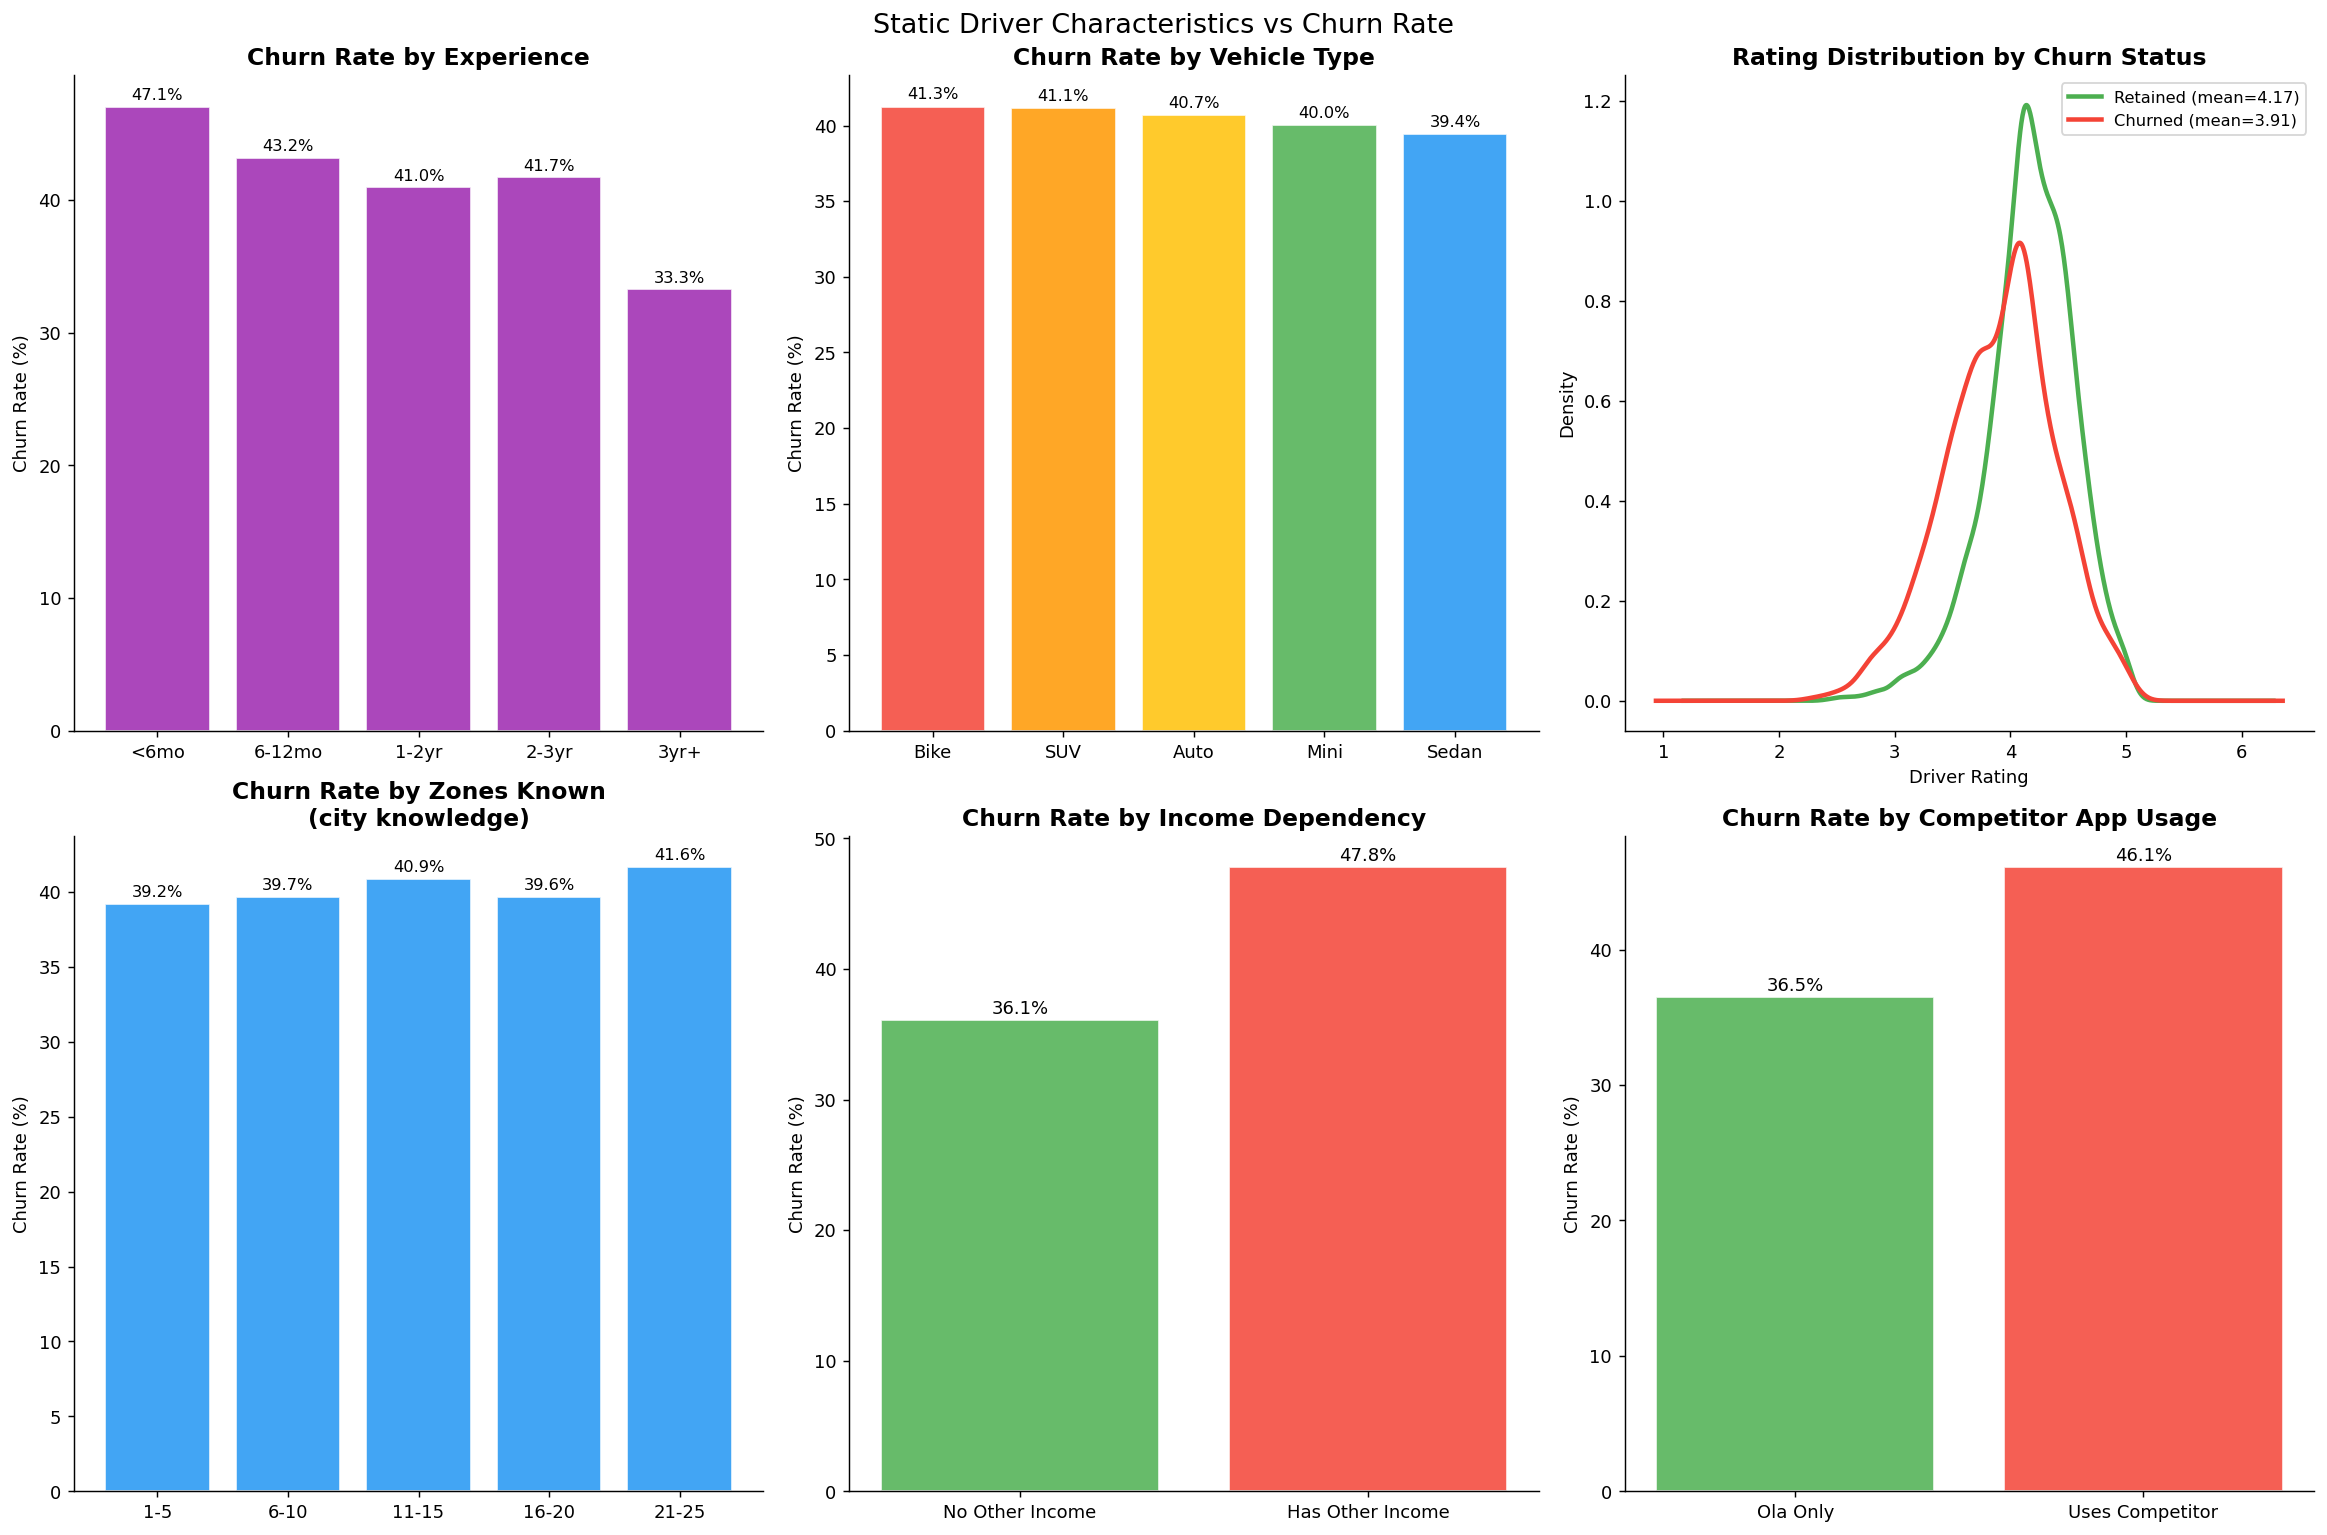

Static characteristic summary:
  Experience effect  : 47.1% (<6mo) vs 33.3% (3yr+)
  Rating difference  : Churned=3.910 Retained=4.169
  Other income lift  : +11.7% churn
  Competitor lift    : +9.6% churn


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Static Driver Characteristics vs Churn Rate",
             fontsize=15)

# ── Experience years ──────────────────────────────────────────
exp_churn = drivers_df.groupby(
    pd.cut(drivers_df["experience_years"],
           bins=[0, 0.5, 1, 2, 3, 10],
           labels=["<6mo","6-12mo","1-2yr","2-3yr","3yr+"])
)["is_churned"].mean() * 100

axes[0][0].bar(exp_churn.index.astype(str),
               exp_churn.values,
               color="#9C27B0", edgecolor="white", alpha=0.85)
axes[0][0].set_title("Churn Rate by Experience")
axes[0][0].set_ylabel("Churn Rate (%)")
for i, v in enumerate(exp_churn.values):
    axes[0][0].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=9)

# ── Vehicle type ──────────────────────────────────────────────
vehicle_churn = drivers_df.groupby("vehicle_type")[
    "is_churned"
].mean() * 100
vehicle_churn = vehicle_churn.sort_values(ascending=False)

colors_v = ["#F44336","#FF9800","#FFC107","#4CAF50","#2196F3"]
axes[0][1].bar(vehicle_churn.index, vehicle_churn.values,
               color=colors_v, edgecolor="white", alpha=0.85)
axes[0][1].set_title("Churn Rate by Vehicle Type")
axes[0][1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(vehicle_churn.values):
    axes[0][1].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=9)

# ── Rating distribution ───────────────────────────────────────
for k in [0, 1]:
    subset = drivers_df[
        drivers_df["is_churned"] == k
    ]["rating"].dropna()
    subset.plot.kde(
        ax=axes[0][2], color=CHURN_COLORS[k],
        linewidth=2.5, label=f"{CHURN_LABELS[k]} "
                             f"(mean={subset.mean():.2f})"
    )
axes[0][2].set_title("Rating Distribution by Churn Status")
axes[0][2].set_xlabel("Driver Rating")
axes[0][2].set_ylabel("Density")
axes[0][2].legend(fontsize=9)

# ── Zones known ───────────────────────────────────────────────
zone_churn = drivers_df.groupby(
    pd.cut(drivers_df["zones_known"],
           bins=[0, 5, 10, 15, 20, 25],
           labels=["1-5","6-10","11-15","16-20","21-25"])
)["is_churned"].mean() * 100

axes[1][0].bar(zone_churn.index.astype(str),
               zone_churn.values,
               color="#2196F3", edgecolor="white", alpha=0.85)
axes[1][0].set_title("Churn Rate by Zones Known\n"
                     "(city knowledge)")
axes[1][0].set_ylabel("Churn Rate (%)")
for i, v in enumerate(zone_churn.values):
    axes[1][0].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=9)

# ── Other income source ───────────────────────────────────────
income_churn = drivers_df.groupby(
    "has_other_income"
)["is_churned"].mean() * 100
axes[1][1].bar(
    ["No Other Income", "Has Other Income"],
    [income_churn[False], income_churn[True]],
    color=["#4CAF50","#F44336"], edgecolor="white", alpha=0.85
)
axes[1][1].set_title("Churn Rate by Income Dependency")
axes[1][1].set_ylabel("Churn Rate (%)")
for i, v in enumerate([income_churn[False], income_churn[True]]):
    axes[1][1].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=10)

# ── Competitor app usage ──────────────────────────────────────
comp_churn = drivers_df.groupby(
    "uses_competitor_app"
)["is_churned"].mean() * 100
axes[1][2].bar(
    ["Ola Only", "Uses Competitor"],
    [comp_churn[False], comp_churn[True]],
    color=["#4CAF50","#F44336"], edgecolor="white", alpha=0.85
)
axes[1][2].set_title("Churn Rate by Competitor App Usage")
axes[1][2].set_ylabel("Churn Rate (%)")
for i, v in enumerate([comp_churn[False], comp_churn[True]]):
    axes[1][2].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../data/processed/eda_01_static_characteristics.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Static characteristic summary:")
print(f"  Experience effect  : "
      f"{exp_churn.iloc[0]:.1f}% (<6mo) vs "
      f"{exp_churn.iloc[-1]:.1f}% (3yr+)")
print(f"  Rating difference  : "
      f"Churned={drivers_df[drivers_df['is_churned']==1]['rating'].mean():.3f} "
      f"Retained={drivers_df[drivers_df['is_churned']==0]['rating'].mean():.3f}")
print(f"  Other income lift  : "
      f"+{income_churn[True] - income_churn[False]:.1f}% churn")
print(f"  Competitor lift    : "
      f"+{comp_churn[True] - comp_churn[False]:.1f}% churn")

## Section 2 — Behavioral Trajectory Analysis

### The Most Important Section in This Notebook

This section answers the question no previous project
could ask: "How does behavior CHANGE over time?"

We compare the week-by-week mean of key metrics
for churned vs retained drivers across all 16 weeks.

### What Perfect Churn Detection Would Look Like
If one chart shows:
  Retained: flat line at 30 rides/week across all 16 weeks
  Churned : flat 30 rides until week 9, then sharp decline
            to 0 by week 13

Then weekly ride count alone would perfectly predict churn.
Reality will be messier — the decline will be gradual,
noisy, and overlapping — which is why we need ML models
to learn the combined pattern across multiple signals.

### The Pre-Churn Window
Weeks 13-16 are the "observation window" — churned drivers
go silent here. But the signal we care about is weeks 9-12:
the pre-churn window where behavior first starts declining.
If we can detect this decline in real-time, we can intervene
before the driver actually leaves.

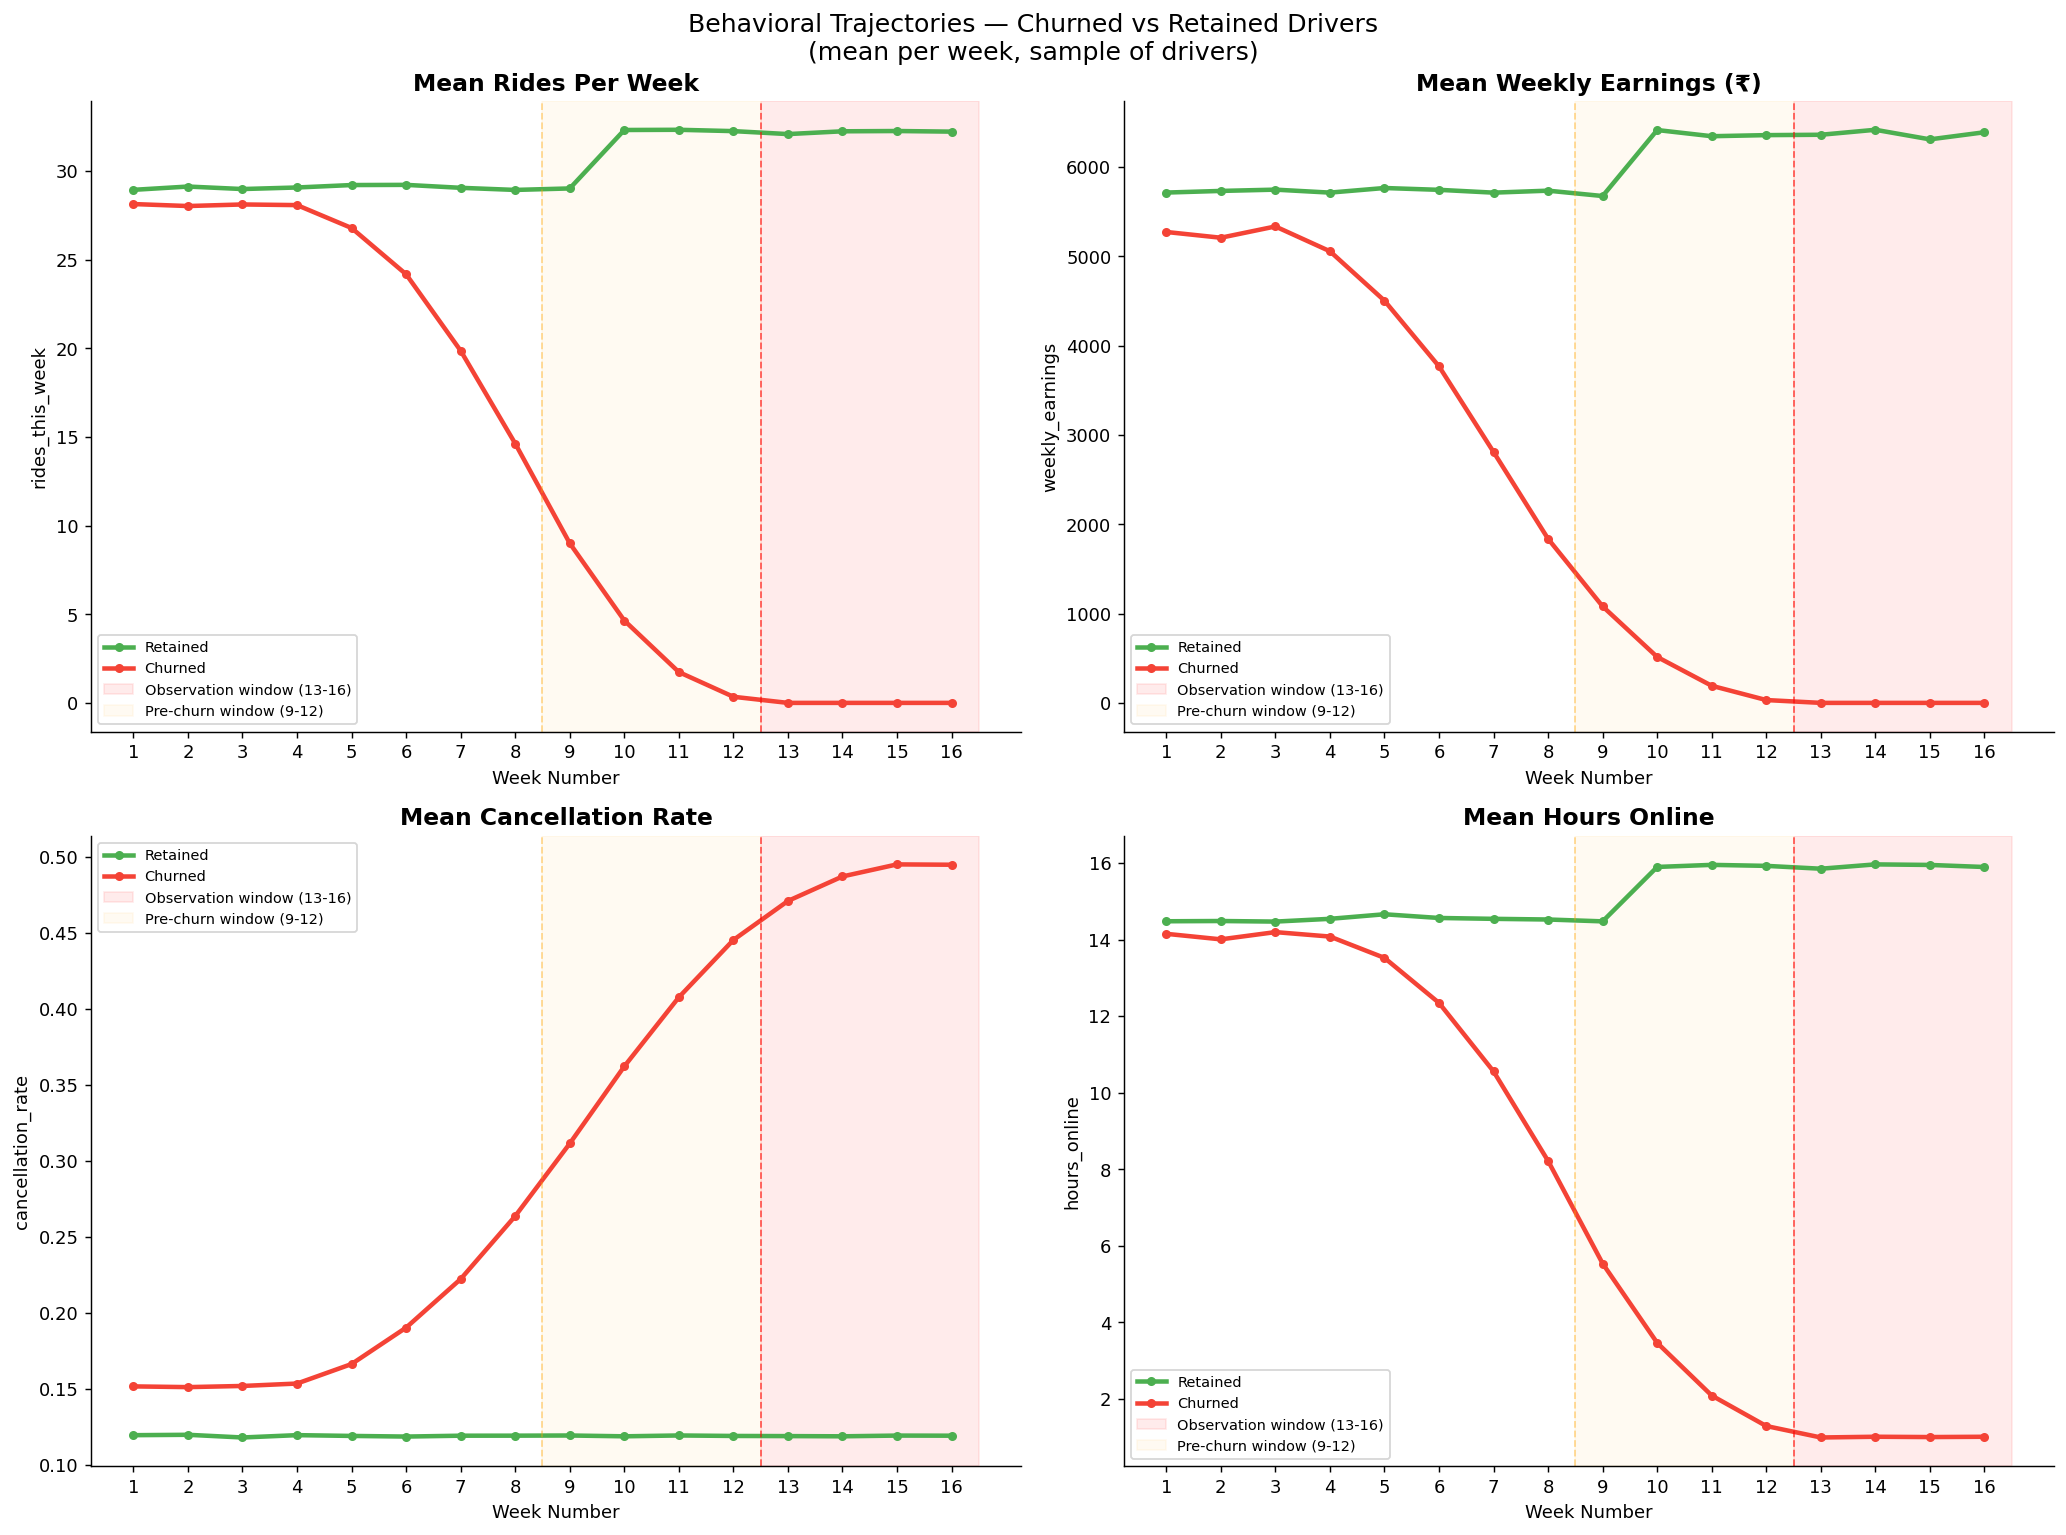

Pre-churn divergence analysis (weeks 9-12 average):

Metric                        Retained      Churned   Difference
-----------------------------------------------------------------
  rides_this_week                31.48         3.93       -87.5%
  weekly_earnings              6199.06       454.56       -92.7%
  cancellation_rate               0.12         0.38      +220.3%
  hours_online                   15.56         3.09       -80.1%


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Behavioral Trajectories — Churned vs Retained Drivers\n"
             "(mean per week, sample of drivers)",
             fontsize=14)

metrics = [
    ("rides_this_week",    "Mean Rides Per Week",     axes[0][0], "#E87722"),
    ("weekly_earnings",    "Mean Weekly Earnings (₹)", axes[0][1], "#2196F3"),
    ("cancellation_rate",  "Mean Cancellation Rate",  axes[1][0], "#F44336"),
    ("hours_online",       "Mean Hours Online",       axes[1][1], "#9C27B0"),
]

for col, title, ax, color in metrics:
    for k in [0, 1]:
        subset = weekly_df[weekly_df["is_churned"] == k]
        mean_by_week = subset.groupby("week_number")[col].mean()

        ax.plot(mean_by_week.index, mean_by_week.values,
                color=CHURN_COLORS[k], linewidth=2.5,
                marker="o", markersize=4,
                label=CHURN_LABELS[k])

    # Shade the observation window
    ax.axvspan(12.5, 16.5, alpha=0.08, color="red",
               label="Observation window (13-16)")
    ax.axvspan(8.5, 12.5, alpha=0.05, color="orange",
               label="Pre-churn window (9-12)")
    ax.axvline(12.5, color="red", linestyle="--",
               linewidth=1, alpha=0.6)
    ax.axvline(8.5, color="orange", linestyle="--",
               linewidth=1, alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Week Number")
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
    ax.set_xticks(range(1, 17))

plt.tight_layout()
plt.savefig("../data/processed/eda_02_behavioral_trajectories.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Quantify the pre-churn divergence
print("Pre-churn divergence analysis (weeks 9-12 average):\n")
print(f"{'Metric':<25} {'Retained':>12} {'Churned':>12} {'Difference':>12}")
print("-" * 65)
for col, title, _, _ in metrics:
    retained_mean = weekly_df[
        (weekly_df["is_churned"]==0) &
        (weekly_df["week_number"].between(9,12))
    ][col].mean()
    churned_mean  = weekly_df[
        (weekly_df["is_churned"]==1) &
        (weekly_df["week_number"].between(9,12))
    ][col].mean()
    diff = churned_mean - retained_mean
    pct  = diff / retained_mean * 100 if retained_mean != 0 else 0
    print(f"  {col:<23} {retained_mean:>12.2f} "
          f"{churned_mean:>12.2f} "
          f"{pct:>+11.1f}%")

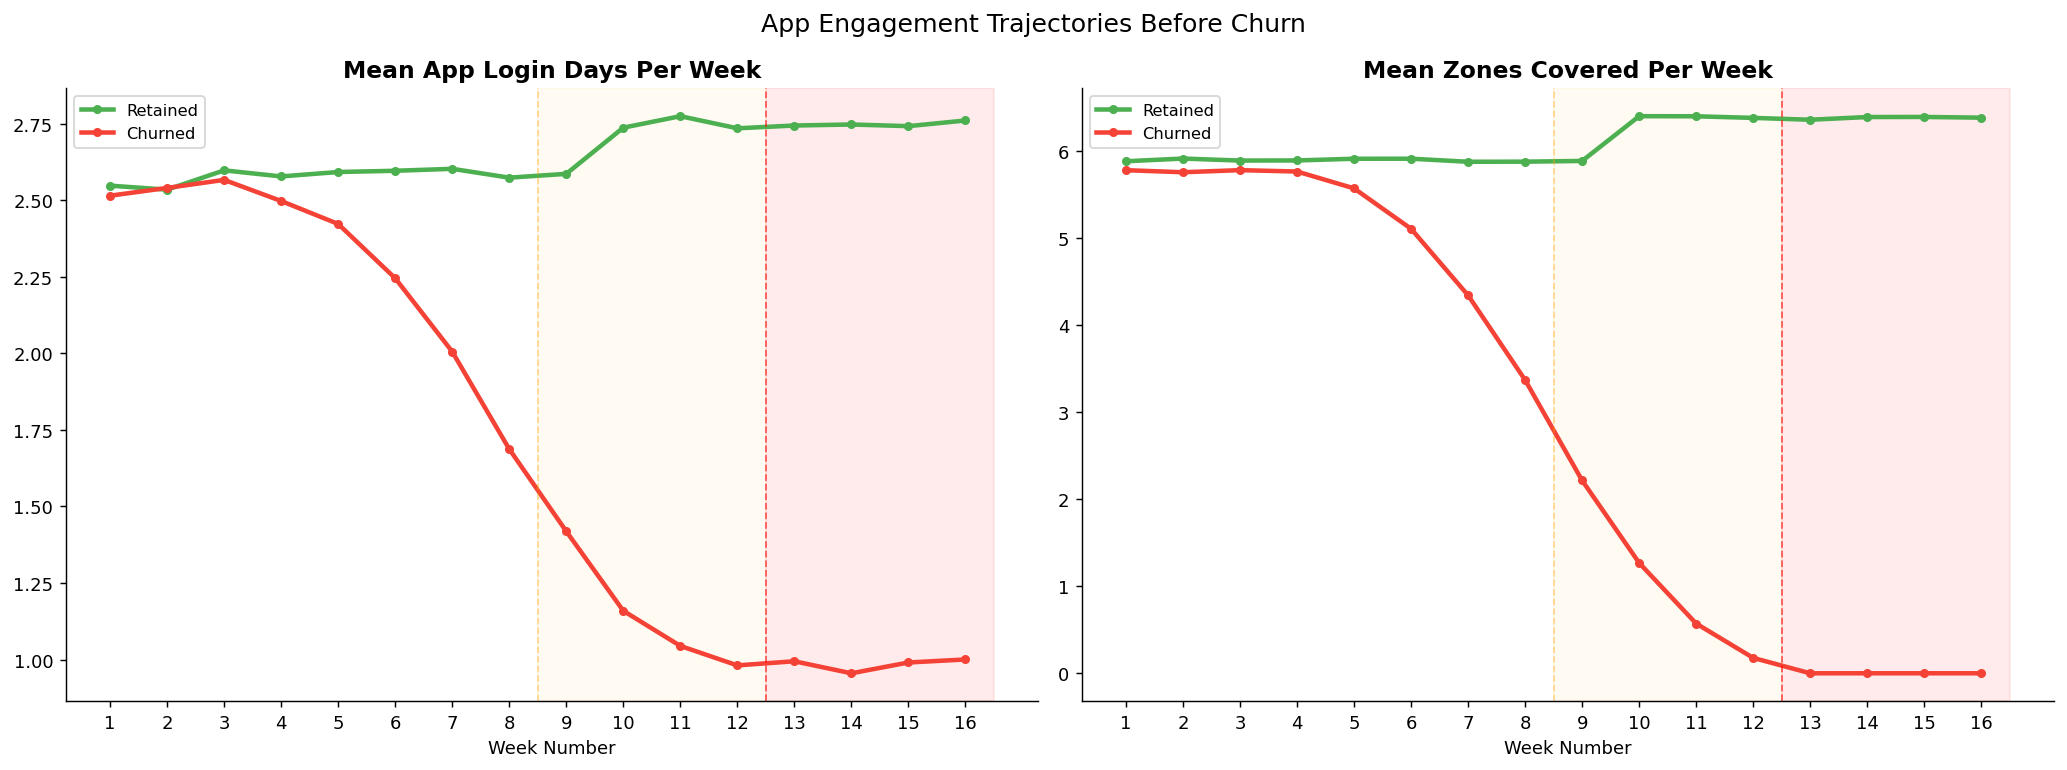

Engagement in final active window (weeks 9-12):
  Retained     login_days: 2.708
  Churned      login_days: 1.151

  Retained     zones_covered: 6.267
  Churned      zones_covered: 1.058



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("App Engagement Trajectories Before Churn", fontsize=14)

engagement_metrics = [
    ("login_days",    "Mean App Login Days Per Week"),
    ("zones_covered", "Mean Zones Covered Per Week"),
]

for idx, (col, title) in enumerate(engagement_metrics):
    for k in [0, 1]:
        subset = weekly_df[weekly_df["is_churned"] == k]
        mean_by_week = subset.groupby("week_number")[col].mean()
        axes[idx].plot(
            mean_by_week.index, mean_by_week.values,
            color=CHURN_COLORS[k], linewidth=2.5,
            marker="o", markersize=4,
            label=CHURN_LABELS[k]
        )
    axes[idx].axvspan(12.5, 16.5, alpha=0.08, color="red")
    axes[idx].axvspan(8.5, 12.5, alpha=0.05, color="orange")
    axes[idx].axvline(12.5, color="red",
                      linestyle="--", linewidth=1, alpha=0.6)
    axes[idx].axvline(8.5, color="orange",
                      linestyle="--", linewidth=1, alpha=0.4)
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Week Number")
    axes[idx].set_xticks(range(1, 17))
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_03_engagement_trajectories.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Engagement in final active window (weeks 9-12):")
for col, title in engagement_metrics:
    for k in [0, 1]:
        mean_val = weekly_df[
            (weekly_df["is_churned"]==k) &
            (weekly_df["week_number"].between(9,12))
        ][col].mean()
        print(f"  {CHURN_LABELS[k]:<12} {col}: {mean_val:.3f}")
    print()

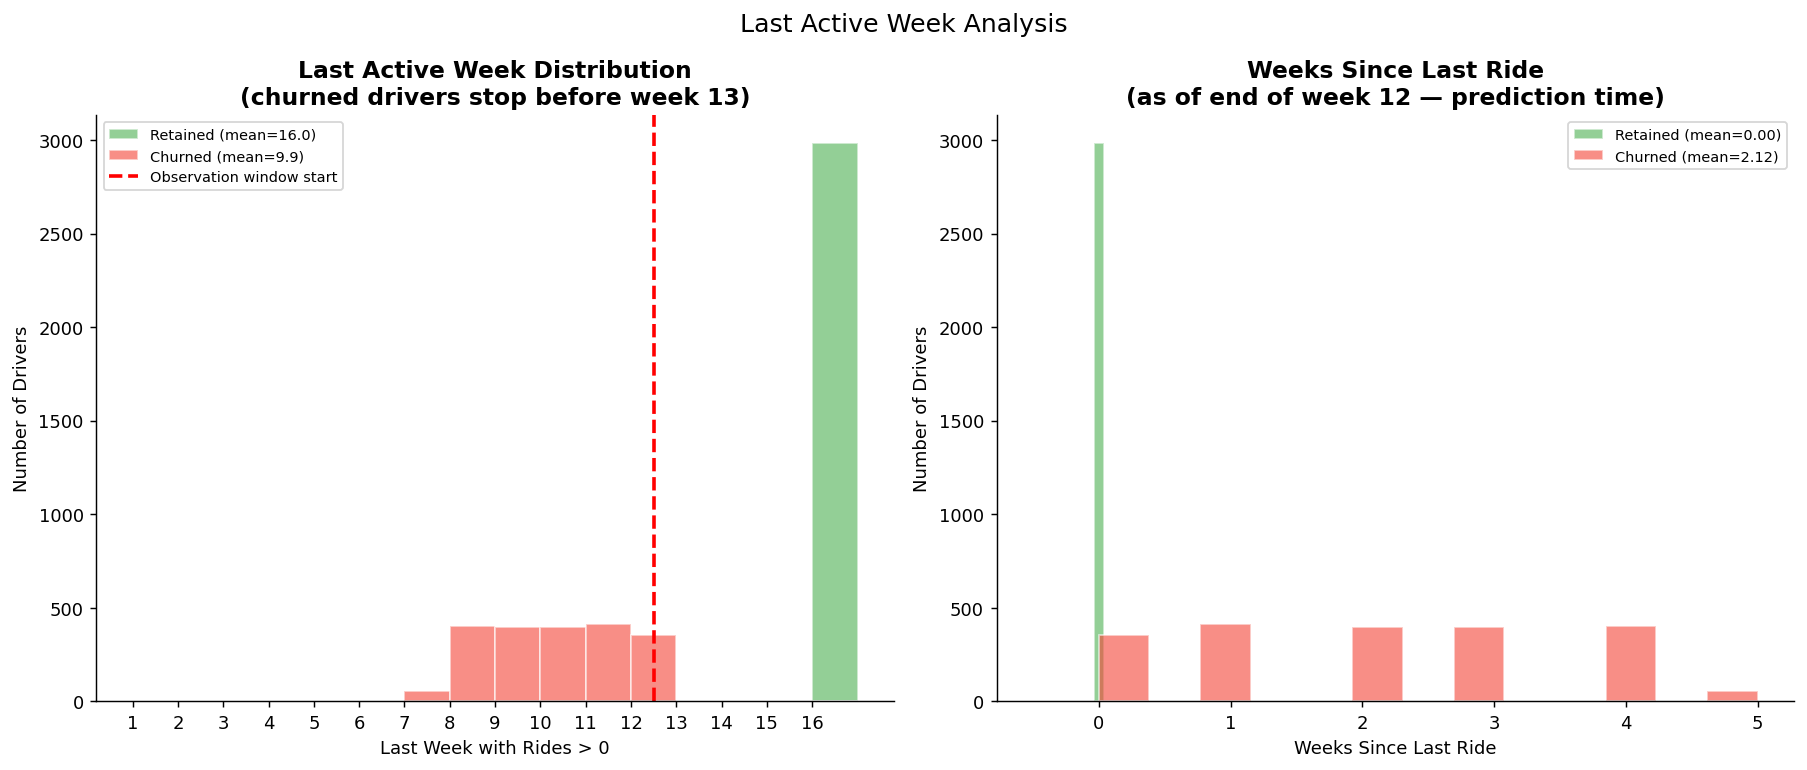

Last active week statistics:
  Retained    : mean=16.00  median=16  min=16  max=16
  Churned     : mean=9.88  median=10  min=7  max=12

Weeks since last ride (as of week 12):
  Retained    : mean=0.000
  Churned     : mean=2.116


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Last Active Week Analysis", fontsize=14)

# For each driver, find the last week they had rides > 0
last_active = weekly_df[
    weekly_df["rides_this_week"] > 0
].groupby("driver_id")["week_number"].max().reset_index()
last_active.columns = ["driver_id", "last_active_week"]
last_active = last_active.merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
)

# Distribution of last active week
for k in [0, 1]:
    subset = last_active[
        last_active["is_churned"] == k
    ]["last_active_week"]
    axes[0].hist(
        subset, bins=16, alpha=0.6,
        color=CHURN_COLORS[k],
        label=f"{CHURN_LABELS[k]} (mean={subset.mean():.1f})",
        edgecolor="white", range=(1, 17)
    )

axes[0].axvline(12.5, color="red", linestyle="--",
                linewidth=2, label="Observation window start")
axes[0].set_title("Last Active Week Distribution\n"
                  "(churned drivers stop before week 13)")
axes[0].set_xlabel("Last Week with Rides > 0")
axes[0].set_ylabel("Number of Drivers")
axes[0].set_xticks(range(1, 17))
axes[0].legend(fontsize=8)

# Weeks since last ride — as of week 12 (prediction time)
last_active["weeks_since_last_ride"] = 12 - last_active[
    "last_active_week"
].clip(upper=12)

for k in [0, 1]:
    subset = last_active[
        last_active["is_churned"] == k
    ]["weeks_since_last_ride"]
    axes[1].hist(
        subset, bins=13, alpha=0.6,
        color=CHURN_COLORS[k],
        label=f"{CHURN_LABELS[k]} (mean={subset.mean():.2f})",
        edgecolor="white"
    )
axes[1].set_title("Weeks Since Last Ride\n"
                  "(as of end of week 12 — prediction time)")
axes[1].set_xlabel("Weeks Since Last Ride")
axes[1].set_ylabel("Number of Drivers")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_04_last_active_week.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Last active week statistics:")
for k in [0, 1]:
    subset = last_active[
        last_active["is_churned"] == k
    ]["last_active_week"]
    print(f"  {CHURN_LABELS[k]:<12}: "
          f"mean={subset.mean():.2f}  "
          f"median={subset.median():.0f}  "
          f"min={subset.min():.0f}  max={subset.max():.0f}")

print("\nWeeks since last ride (as of week 12):")
for k in [0, 1]:
    subset = last_active[
        last_active["is_churned"] == k
    ]["weeks_since_last_ride"]
    print(f"  {CHURN_LABELS[k]:<12}: mean={subset.mean():.3f}")

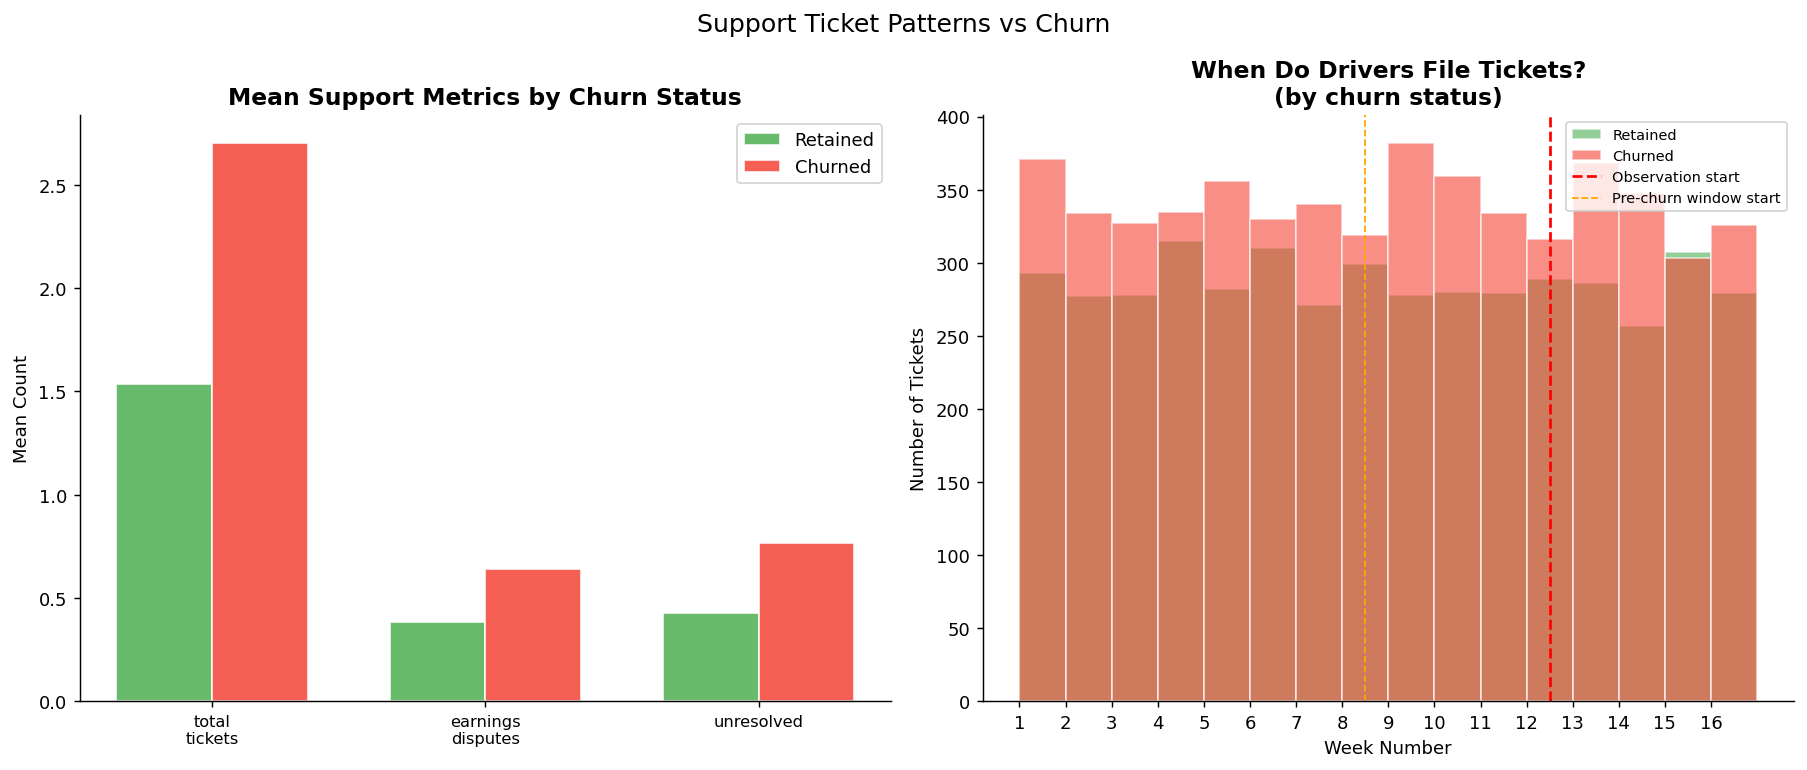

Support ticket comparison:
            total_tickets  earnings_disputes  unresolved
is_churned                                              
0                   1.534              0.386       0.427
1                   2.704              0.638       0.766


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Support Ticket Patterns vs Churn", fontsize=14)

# Ticket count by churn status
ticket_summary = drivers_df.merge(
    tickets_df.groupby("driver_id").agg(
        total_tickets      = ("category", "count"),
        earnings_disputes  = ("category",
            lambda x: (x=="earnings_dispute").sum()),
        unresolved         = ("resolution",
            lambda x: (x=="pending").sum()),
        avg_satisfaction   = ("satisfaction", "mean")
    ).reset_index(),
    on="driver_id", how="left"
).fillna(0)

ticket_cols = [
    "total_tickets", "earnings_disputes", "unresolved"
]
ticket_means = ticket_summary.groupby("is_churned")[
    ticket_cols
].mean()

x = np.arange(len(ticket_cols))
width = 0.35
axes[0].bar(x - width/2,
            [ticket_means.loc[0, c] for c in ticket_cols],
            width, label="Retained",
            color=CHURN_COLORS[0], edgecolor="white", alpha=0.85)
axes[0].bar(x + width/2,
            [ticket_means.loc[1, c] for c in ticket_cols],
            width, label="Churned",
            color=CHURN_COLORS[1], edgecolor="white", alpha=0.85)
axes[0].set_title("Mean Support Metrics by Churn Status")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [c.replace("_","\n") for c in ticket_cols], fontsize=9
)
axes[0].set_ylabel("Mean Count")
axes[0].legend()

# Ticket timing — when do churned drivers file tickets?
churned_ticket_weeks = tickets_df.merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
)

for k in [0, 1]:
    subset = churned_ticket_weeks[
        churned_ticket_weeks["is_churned"] == k
    ]["ticket_week"]
    axes[1].hist(
        subset, bins=16, alpha=0.6,
        color=CHURN_COLORS[k],
        label=CHURN_LABELS[k],
        edgecolor="white", range=(1, 17)
    )
axes[1].axvline(12.5, color="red", linestyle="--",
                linewidth=1.5, label="Observation start")
axes[1].axvline(8.5, color="orange", linestyle="--",
                linewidth=1, label="Pre-churn window start")
axes[1].set_title("When Do Drivers File Tickets?\n"
                  "(by churn status)")
axes[1].set_xlabel("Week Number")
axes[1].set_ylabel("Number of Tickets")
axes[1].set_xticks(range(1, 17))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_05_support_tickets.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Support ticket comparison:")
print(ticket_means.round(3))

RFM FRAMEWORK ANALYSIS

Recency — Frequency — Monetary

The three universal dimensions of customer/driver engagement



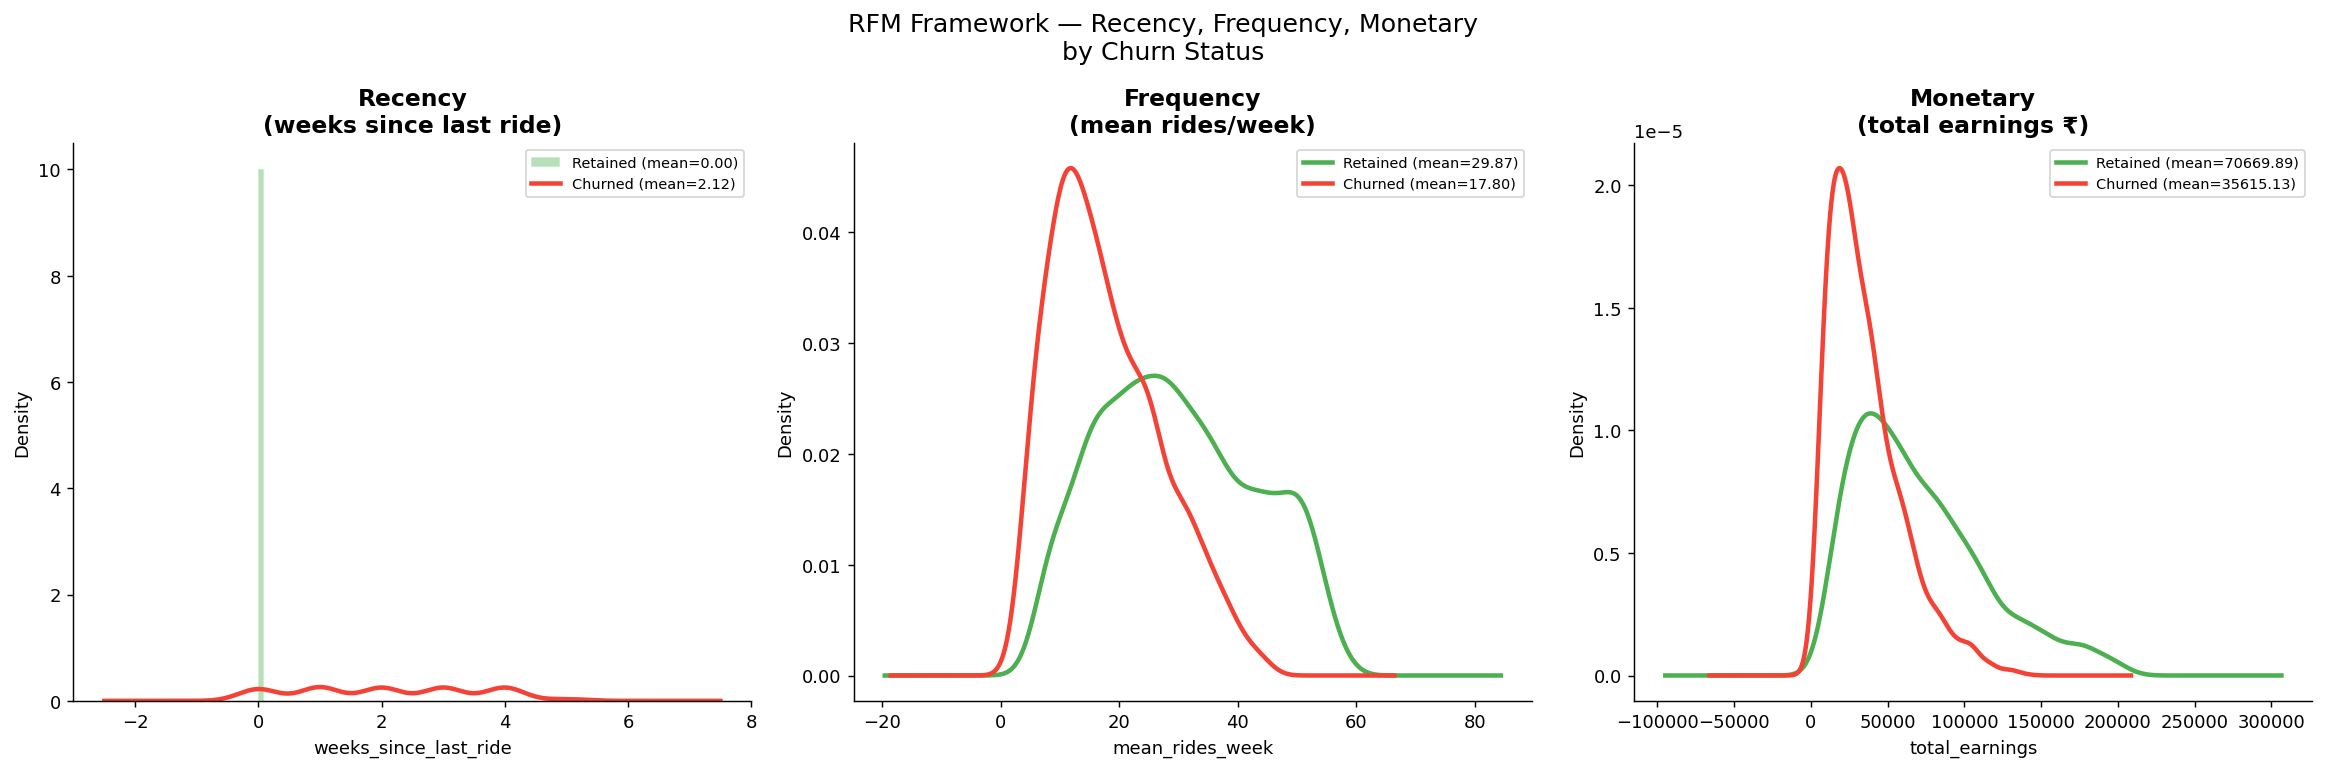

RFM Summary by Churn Status:

Metric                             Retained      Churned
--------------------------------------------------------
  weeks_since_last_ride                0.00         2.12
  mean_rides_week                     29.87        17.80
  total_earnings                   70669.89     35615.13


In [9]:
print("RFM FRAMEWORK ANALYSIS\n")
print("Recency — Frequency — Monetary\n")
print("The three universal dimensions of customer/driver engagement\n")

# Compute RFM for each driver from weeks 1-12
active_weeks = weekly_df[weekly_df["week_number"].between(1, 12)]

rfm = active_weeks.groupby("driver_id").agg(
    # Recency — last week with rides
    last_ride_week    = ("rides_this_week",
        lambda x: x[x > 0].index[-1]
        if any(x > 0) else 0),
    # Frequency — mean rides per week
    mean_rides_week   = ("rides_this_week", "mean"),
    total_rides       = ("rides_this_week", "sum"),
    # Monetary — total earnings
    total_earnings    = ("weekly_earnings", "sum"),
    mean_earnings     = ("weekly_earnings", "mean"),
    # Engagement
    mean_login_days   = ("login_days", "mean"),
).reset_index()

# Fix last_ride_week — it captured index not week_number
# Recompute properly
last_ride = active_weeks[
    active_weeks["rides_this_week"] > 0
].groupby("driver_id")["week_number"].max().reset_index()
last_ride.columns = ["driver_id", "last_ride_week"]

rfm = rfm.drop(columns=["last_ride_week"]).merge(
    last_ride, on="driver_id", how="left"
)
rfm["last_ride_week"] = rfm["last_ride_week"].fillna(0)
rfm["weeks_since_last_ride"] = 12 - rfm["last_ride_week"]

rfm = rfm.merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("RFM Framework — Recency, Frequency, Monetary\n"
             "by Churn Status", fontsize=14)

rfm_metrics = [
    ("weeks_since_last_ride", "Recency\n(weeks since last ride)", axes[0]),
    ("mean_rides_week",       "Frequency\n(mean rides/week)",     axes[1]),
    ("total_earnings",        "Monetary\n(total earnings ₹)",     axes[2]),
]

for col, title, ax in rfm_metrics:
    for k in [0, 1]:
        subset = rfm[rfm["is_churned"]==k][col].dropna()
        if len(subset) < 2 or subset.nunique() == 1:
            if len(subset) > 0:
                ax.hist(subset, bins=10, density=True,
                        alpha=0.4, color=CHURN_COLORS[k],
                        label=f"{CHURN_LABELS[k]} "
                              f"(mean={subset.mean():.2f})",
                        edgecolor="white")
        else:
            subset.plot.kde(
                ax=ax, color=CHURN_COLORS[k],
                linewidth=2.5,
                label=f"{CHURN_LABELS[k]} "
                      f"(mean={subset.mean():.2f})"
            )
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_06_rfm_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("RFM Summary by Churn Status:")
print(f"\n{'Metric':<30} {'Retained':>12} {'Churned':>12}")
print("-" * 56)
for col, title, _ in rfm_metrics:
    ret_mean  = rfm[rfm["is_churned"]==0][col].mean()
    churn_mean= rfm[rfm["is_churned"]==1][col].mean()
    print(f"  {col:<28} {ret_mean:>12.2f} {churn_mean:>12.2f}")

TREND ANALYSIS — The Most Important EDA Section

Computing ride volume SLOPE for each driver

A negative slope = declining engagement = churn risk



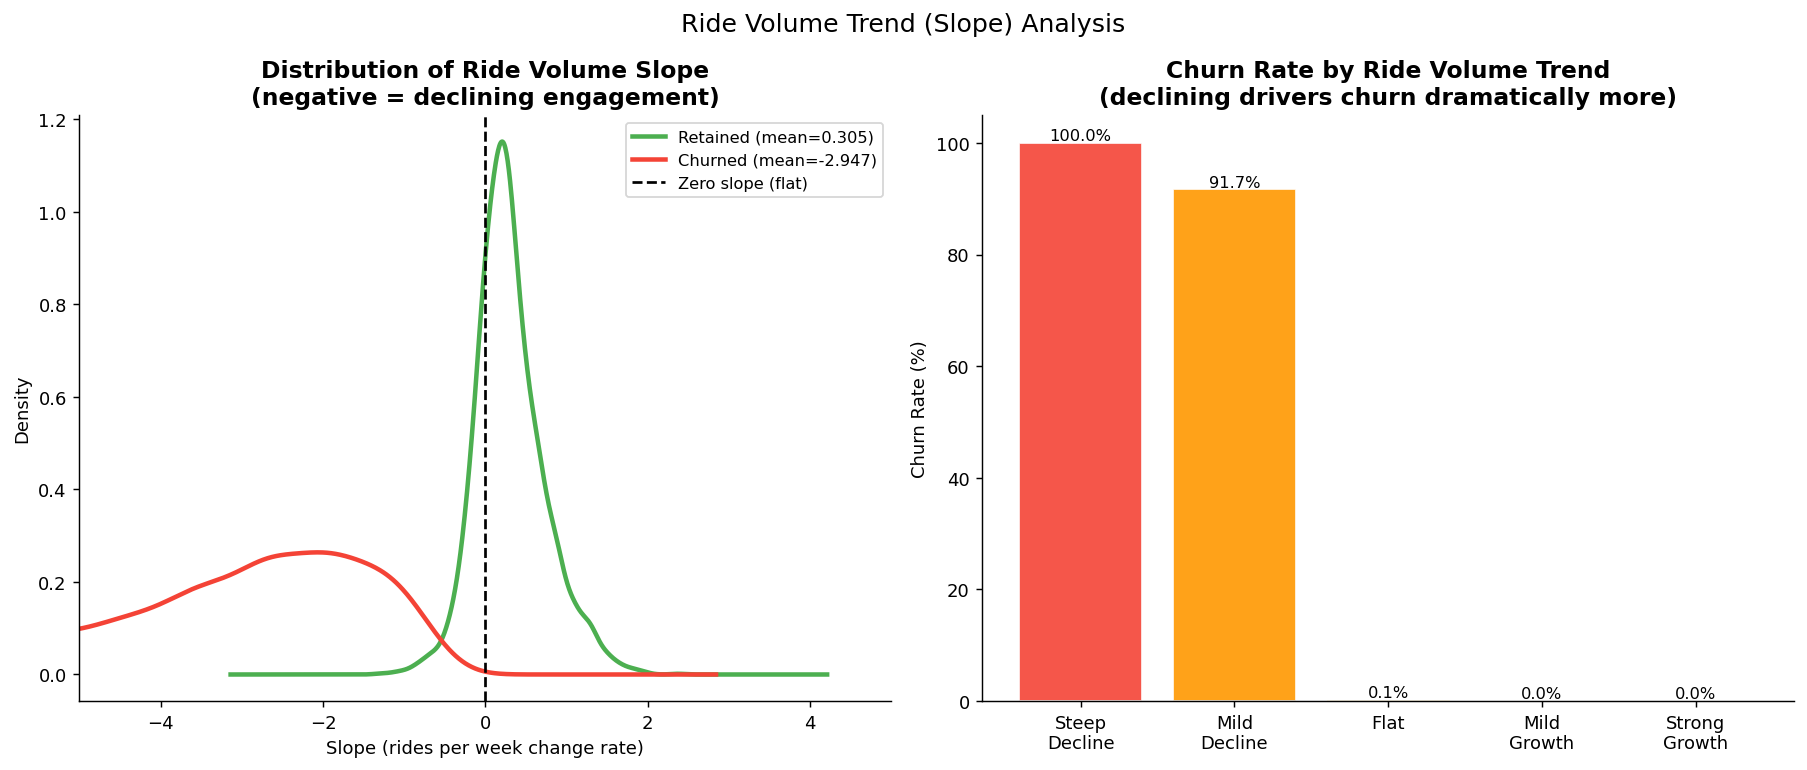

Ride slope by churn status:
  Retained    : 0.3053 rides/week change
  Churned     : -2.9470 rides/week change

Churn rate by slope bucket:
slope_bucket
Steep\nDecline   100.000
Mild\nDecline     91.700
Flat               0.100
Mild\nGrowth       0.000
Strong\nGrowth     0.000
Name: is_churned, dtype: float64


In [10]:
print("TREND ANALYSIS — The Most Important EDA Section\n")
print("Computing ride volume SLOPE for each driver\n")
print("A negative slope = declining engagement = churn risk\n")

# For each driver, compute the linear trend in rides
# over weeks 1-12 (slope of ride count over time)
from numpy.polynomial import polynomial as P

def compute_slope(series):
    """Fit a linear trend to weekly ride counts."""
    weeks  = np.arange(1, len(series) + 1)
    values = series.values
    if len(values) < 2 or np.all(values == 0):
        return 0.0
    coeffs = np.polyfit(weeks, values, 1)
    return round(coeffs[0], 4)  # slope

active_weeks_12 = weekly_df[
    weekly_df["week_number"].between(1, 12)
]

driver_slopes = active_weeks_12.groupby("driver_id")[
    "rides_this_week"
].apply(compute_slope).reset_index()
driver_slopes.columns = ["driver_id", "ride_slope"]

driver_slopes = driver_slopes.merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Ride Volume Trend (Slope) Analysis", fontsize=14)

# KDE of slope by churn status
for k in [0, 1]:
    subset = driver_slopes[
        driver_slopes["is_churned"]==k
    ]["ride_slope"]
    subset.plot.kde(
        ax=axes[0], color=CHURN_COLORS[k],
        linewidth=2.5,
        label=f"{CHURN_LABELS[k]} (mean={subset.mean():.3f})"
    )
axes[0].axvline(0, color="black", linestyle="--",
                linewidth=1.5, label="Zero slope (flat)")
axes[0].set_title("Distribution of Ride Volume Slope\n"
                  "(negative = declining engagement)")
axes[0].set_xlabel("Slope (rides per week change rate)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)
axes[0].set_xlim(-5, 5)

# Slope buckets vs churn rate
driver_slopes["slope_bucket"] = pd.cut(
    driver_slopes["ride_slope"],
    bins=[-10, -2, -0.5, 0.5, 2, 10],
    labels=["Steep\nDecline","Mild\nDecline",
            "Flat","Mild\nGrowth","Strong\nGrowth"]
)
slope_churn = driver_slopes.groupby(
    "slope_bucket", observed=True
)["is_churned"].mean() * 100

colors_s = ["#F44336","#FF9800","#FFC107","#8BC34A","#4CAF50"]
axes[1].bar(slope_churn.index.astype(str), slope_churn.values,
            color=colors_s, edgecolor="white", alpha=0.9)
axes[1].set_title("Churn Rate by Ride Volume Trend\n"
                  "(declining drivers churn dramatically more)")
axes[1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(slope_churn.values):
    axes[1].text(i, v+0.5, f"{v:.1f}%",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_07_trend_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Ride slope by churn status:")
for k in [0, 1]:
    mean_slope = driver_slopes[
        driver_slopes["is_churned"]==k
    ]["ride_slope"].mean()
    print(f"  {CHURN_LABELS[k]:<12}: {mean_slope:.4f} rides/week change")

print("\nChurn rate by slope bucket:")
print(slope_churn.round(1))

LAST 4 WEEKS vs FIRST 8 WEEKS COMPARISON

The most direct pre-churn signal in the dataset



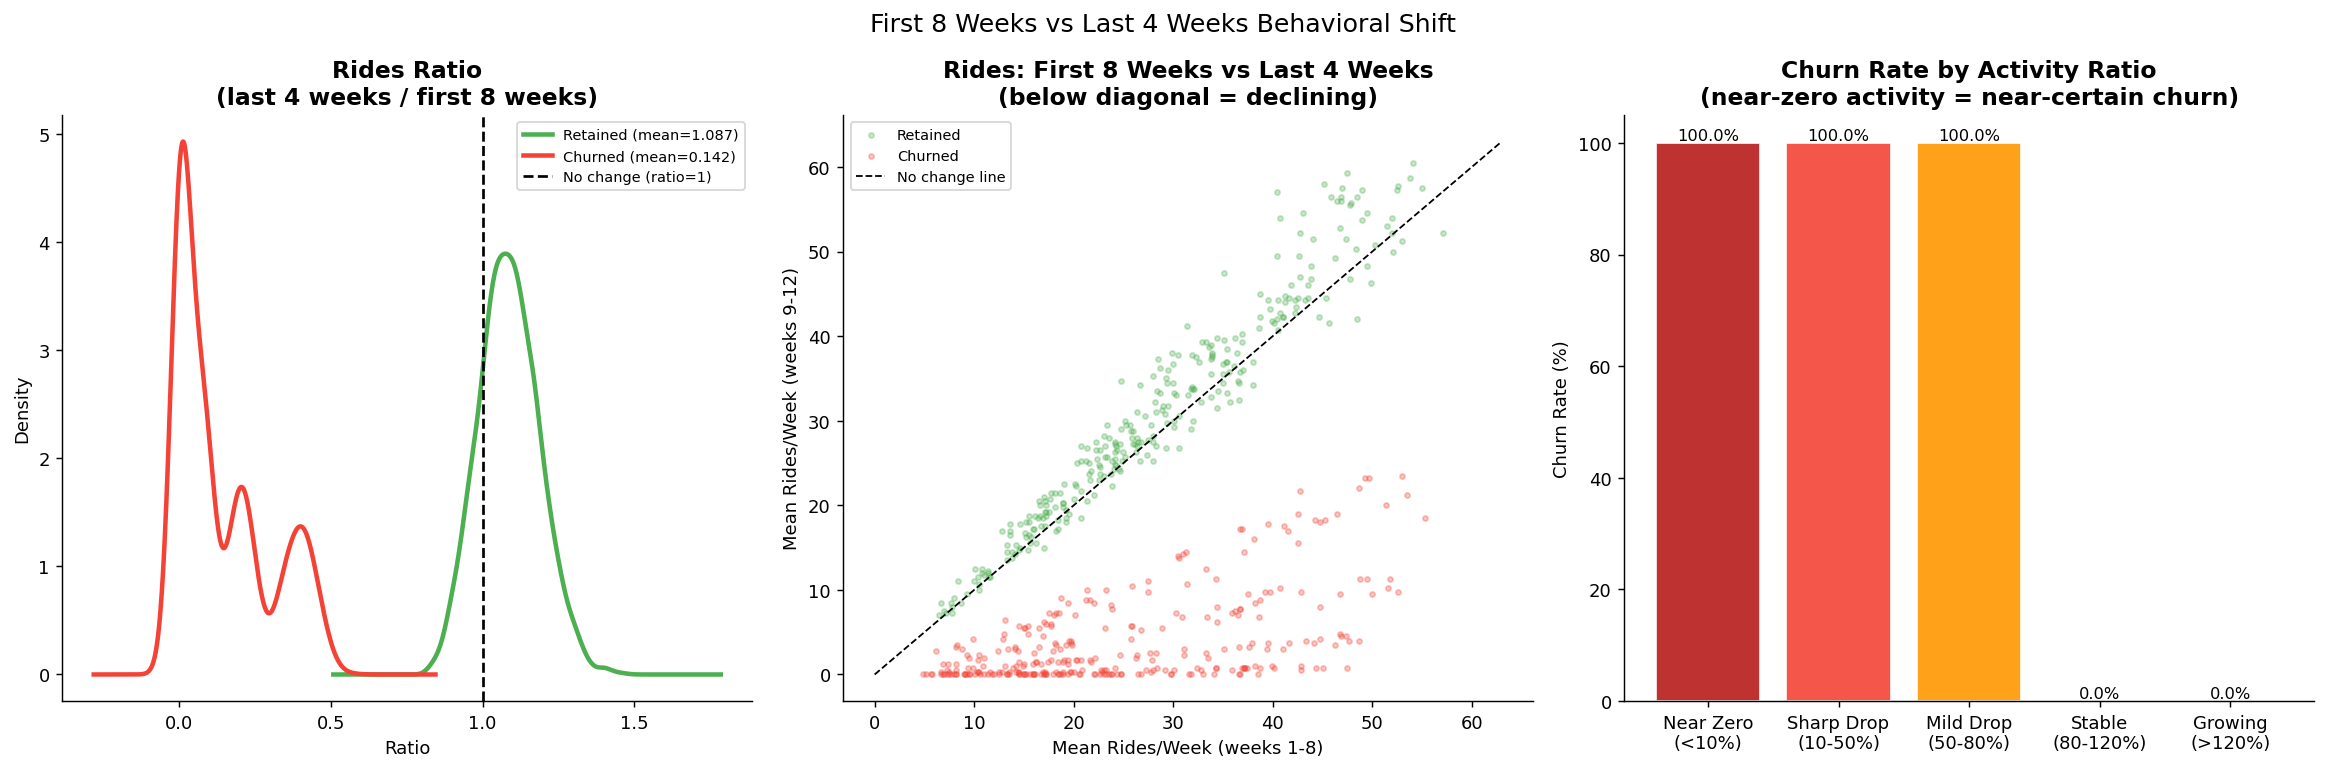

Activity ratio by churn status:
  Retained    : 1.0873 ratio
  Churned     : 0.1418 ratio

Churn rate by activity ratio bucket:
ratio_bucket
Near Zero\n(<10%)      100.000
Sharp Drop\n(10-50%)   100.000
Mild Drop\n(50-80%)    100.000
Stable\n(80-120%)        0.000
Growing\n(>120%)         0.000
Name: is_churned, dtype: float64


In [11]:
print("LAST 4 WEEKS vs FIRST 8 WEEKS COMPARISON\n")
print("The most direct pre-churn signal in the dataset\n")

# Compute for each driver:
# mean rides in weeks 1-8 (baseline behavior)
# mean rides in weeks 9-12 (pre-observation behavior)
# ratio: (weeks 9-12) / (weeks 1-8)

first_8 = weekly_df[
    weekly_df["week_number"].between(1, 8)
].groupby("driver_id")["rides_this_week"].mean().reset_index()
first_8.columns = ["driver_id", "mean_rides_first8"]

last_4  = weekly_df[
    weekly_df["week_number"].between(9, 12)
].groupby("driver_id")["rides_this_week"].mean().reset_index()
last_4.columns = ["driver_id", "mean_rides_last4"]

window_compare = first_8.merge(last_4, on="driver_id").merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
)
window_compare["rides_ratio"] = (
    window_compare["mean_rides_last4"] /
    window_compare["mean_rides_first8"].replace(0, np.nan)
).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("First 8 Weeks vs Last 4 Weeks Behavioral Shift",
             fontsize=14)

# Rides ratio distribution
for k in [0, 1]:
    subset = window_compare[
        window_compare["is_churned"]==k
    ]["rides_ratio"].clip(0, 3)
    subset.plot.kde(
        ax=axes[0], color=CHURN_COLORS[k],
        linewidth=2.5,
        label=f"{CHURN_LABELS[k]} (mean={subset.mean():.3f})"
    )
axes[0].axvline(1.0, color="black", linestyle="--",
                linewidth=1.5, label="No change (ratio=1)")
axes[0].set_title("Rides Ratio\n(last 4 weeks / first 8 weeks)")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# Scatter: first8 vs last4
for k in [0, 1]:
    subset = window_compare[
        window_compare["is_churned"]==k
    ].sample(min(300, len(
        window_compare[window_compare["is_churned"]==k]
    )), random_state=42)
    axes[1].scatter(
        subset["mean_rides_first8"],
        subset["mean_rides_last4"],
        alpha=0.3, color=CHURN_COLORS[k], s=8,
        label=CHURN_LABELS[k]
    )
max_val = max(window_compare["mean_rides_first8"].max(),
              window_compare["mean_rides_last4"].max())
axes[1].plot([0, max_val], [0, max_val], "black",
             linestyle="--", linewidth=1, label="No change line")
axes[1].set_title("Rides: First 8 Weeks vs Last 4 Weeks\n"
                  "(below diagonal = declining)")
axes[1].set_xlabel("Mean Rides/Week (weeks 1-8)")
axes[1].set_ylabel("Mean Rides/Week (weeks 9-12)")
axes[1].legend(fontsize=8)

# Ratio buckets vs churn rate
window_compare["ratio_bucket"] = pd.cut(
    window_compare["rides_ratio"],
    bins=[-0.1, 0.1, 0.5, 0.8, 1.2, 5],
    labels=["Near Zero\n(<10%)", "Sharp Drop\n(10-50%)",
            "Mild Drop\n(50-80%)", "Stable\n(80-120%)",
            "Growing\n(>120%)"]
)
ratio_churn = window_compare.groupby(
    "ratio_bucket", observed=True
)["is_churned"].mean() * 100

colors_r = ["#B71C1C","#F44336","#FF9800","#4CAF50","#1B5E20"]
axes[2].bar(ratio_churn.index.astype(str), ratio_churn.values,
            color=colors_r, edgecolor="white", alpha=0.9)
axes[2].set_title("Churn Rate by Activity Ratio\n"
                  "(near-zero activity = near-certain churn)")
axes[2].set_ylabel("Churn Rate (%)")
for i, v in enumerate(ratio_churn.values):
    axes[2].text(i, v+0.5, f"{v:.1f}%",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_08_window_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Activity ratio by churn status:")
for k in [0, 1]:
    mean_ratio = window_compare[
        window_compare["is_churned"]==k
    ]["rides_ratio"].mean()
    print(f"  {CHURN_LABELS[k]:<12}: {mean_ratio:.4f} ratio")

print("\nChurn rate by activity ratio bucket:")
print(ratio_churn.round(1))

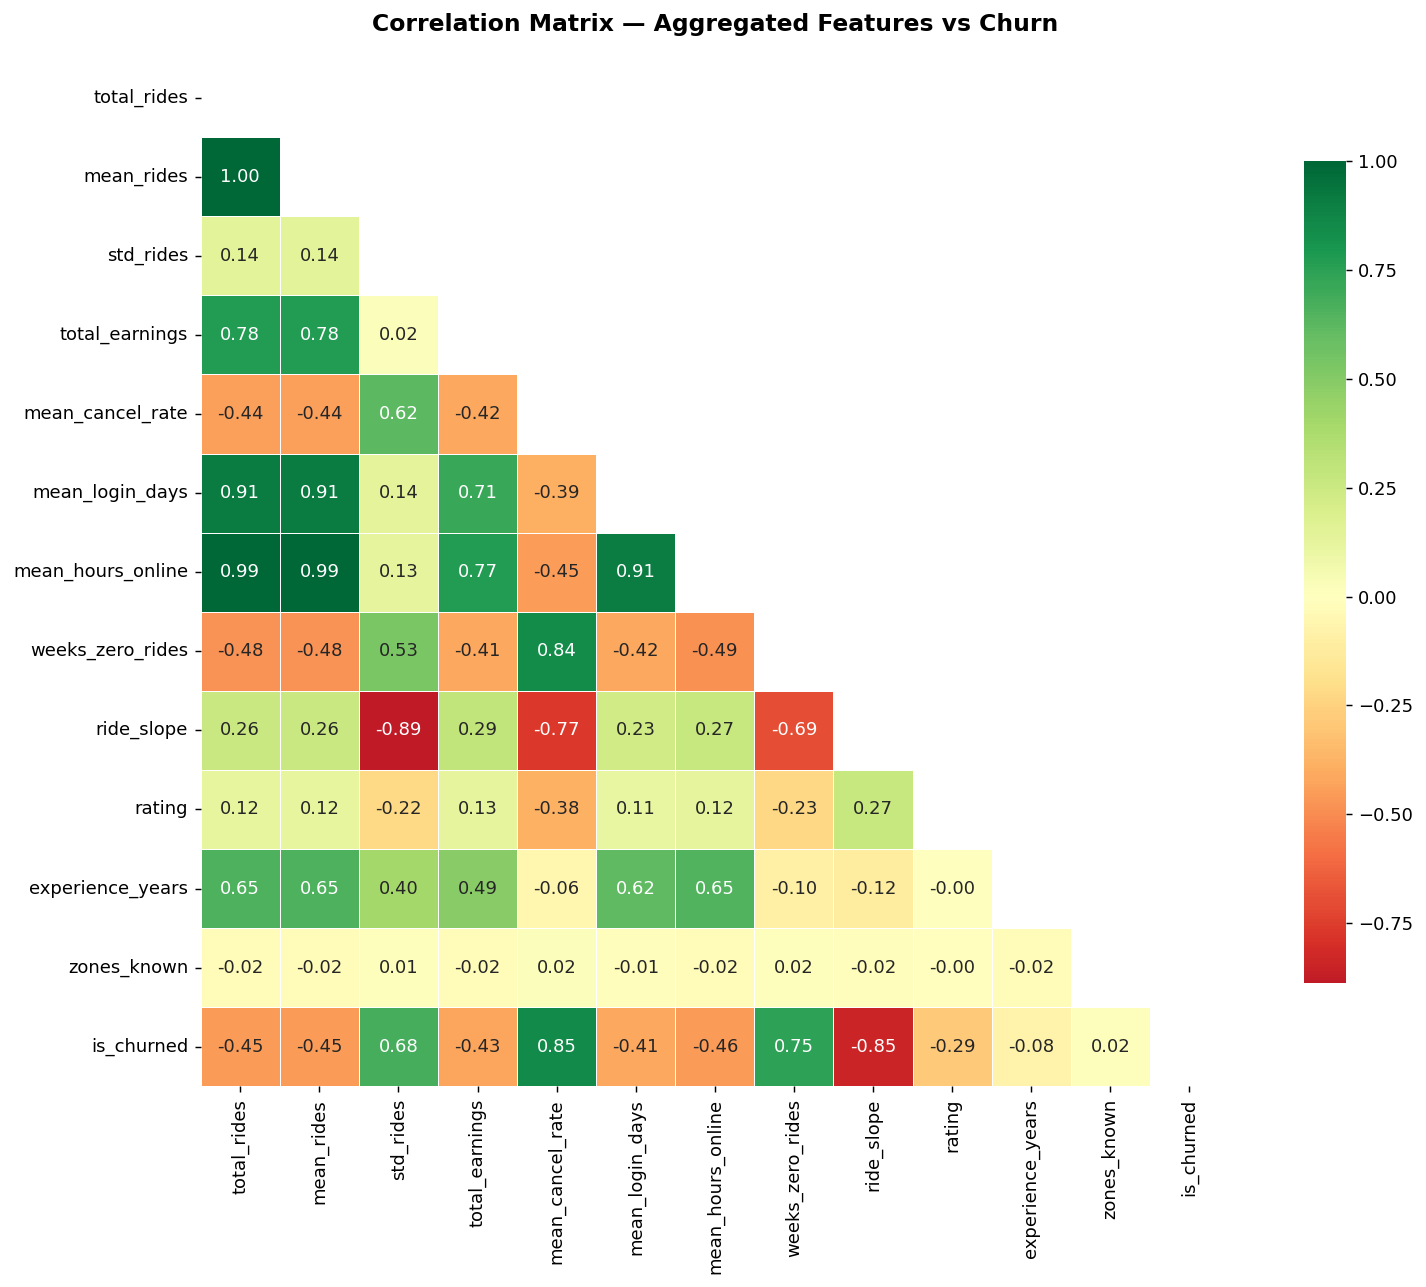

Correlation with is_churned (sorted):
mean_cancel_rate    0.854
ride_slope          0.848
weeks_zero_rides    0.747
std_rides           0.682
mean_hours_online   0.460
total_rides         0.454
mean_rides          0.454
total_earnings      0.427
mean_login_days     0.411
rating              0.288
experience_years    0.081
zones_known         0.016
Name: is_churned, dtype: float64


In [12]:
# Build driver-level aggregated metrics for correlation
agg_features = weekly_df[
    weekly_df["week_number"].between(1,12)
].groupby("driver_id").agg(
    total_rides       = ("rides_this_week", "sum"),
    mean_rides        = ("rides_this_week", "mean"),
    std_rides         = ("rides_this_week", "std"),
    total_earnings    = ("weekly_earnings", "sum"),
    mean_cancel_rate  = ("cancellation_rate", "mean"),
    mean_login_days   = ("login_days", "mean"),
    mean_hours_online = ("hours_online", "mean"),
    weeks_zero_rides  = ("rides_this_week",
                         lambda x: (x==0).sum()),
).reset_index()

agg_features = agg_features.merge(
    drivers_df[["driver_id","is_churned","rating",
                "experience_years","zones_known"]],
    on="driver_id"
).merge(driver_slopes[["driver_id","ride_slope"]], on="driver_id")

corr_cols = [
    "total_rides","mean_rides","std_rides",
    "total_earnings","mean_cancel_rate","mean_login_days",
    "mean_hours_online","weeks_zero_rides","ride_slope",
    "rating","experience_years","zones_known","is_churned"
]
corr_df  = agg_features[corr_cols].copy()
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={"shrink":0.8}
)
ax.set_title("Correlation Matrix — Aggregated Features vs Churn",
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eda_09_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with is_churned (sorted):")
churn_corr = corr_mat["is_churned"].drop(
    "is_churned"
).abs().sort_values(ascending=False)
print(churn_corr.round(4))

## EDA Summary — Key Findings for Feature Engineering

### Pre-Churn Behavioral Divergence (Weeks 9-12)

| Metric | Retained | Churned | Difference |
|---|---|---|---|
| rides_this_week | 31.48 | **3.93** | **-87.5%** |
| weekly_earnings | ₹6,199 | **₹455** | **-92.7%** |
| cancellation_rate | 0.12 | **0.38** | **+220.3%** |
| hours_online | 15.56 | **3.09** | **-80.1%** |

This is the most dramatic behavioral divergence in any EDA
we have run across all five projects. By weeks 9-12 —
still within the "active window" — churning drivers are
already showing 87.5% fewer rides, 92.7% lower earnings,
and 220% higher cancellation rates than retained drivers.

The business interpretation is stark: by the time a driver
enters weeks 9-12, a churning driver is essentially already
gone. They are completing fewer than 4 rides per week
versus 31 for retained drivers. Their earnings are ₹455
per week versus ₹6,199. Their cancellation rate is 3x
the normal level — suggesting frustration and carelessness.

This means our prediction window is generous. We do not
need to detect churn in week 12. The signals are already
dramatically visible from week 9 onward — giving the
retention team a 3-4 week window to intervene.

---

### RFM Framework Summary

| Dimension | Retained | Churned | Ratio |
|---|---|---|---|
| Recency (weeks since last ride) | **0.00** | **2.12** | ∞ |
| Frequency (mean rides/week) | **29.87** | **17.80** | 1.68x |
| Monetary (total earnings) | **₹70,670** | **₹35,615** | 1.98x |

All three RFM dimensions clearly separate churned from
retained drivers. The most powerful is Recency — retained
drivers have zero weeks since their last ride (they were
active right up to week 12), while churned drivers have
been silent for an average of 2.12 weeks before the
observation window even begins. The Monetary dimension
shows churned drivers earned only half what retained
drivers earned over the active window — financial
dissatisfaction encoded in the data.

---

### Trend Analysis — The Strongest Individual Signal

| Status | Mean Weekly Slope | Interpretation |
|---|---|---|
| Retained | **+0.305 rides/week** | Slowly growing — engaged |
| Churned | **-2.947 rides/week** | Declining sharply — disengaging |

| Slope Bucket | Churn Rate |
|---|---|
| Steep Decline | **100.0%** |
| Mild Decline | **91.7%** |
| Flat | **0.1%** |
| Mild Growth | **0.0%** |
| Strong Growth | **0.0%** |

This is a near-perfect binary signal. Any driver with a
negative ride slope (declining week-over-week) is churning
at 91-100% rate. Any driver with a flat or positive slope
is churning at near 0%.

The ride slope has a correlation of **0.848** with
is_churned — the second strongest feature in the entire
dataset. This single number, computed from 12 weeks of
data, almost perfectly predicts churn outcome.

This is why "trend features" are the heart of churn
prediction. The current value of rides_this_week tells
you where the driver is. The slope tells you where they
are going. Where they are going is what matters.

---

### Activity Ratio — The Most Business-Interpretable Signal

| Status | Mean Ratio | Interpretation |
|---|---|---|
| Retained | **1.087** | Doing slightly MORE than before |
| Churned | **0.142** | Doing only 14% of what they used to |

| Ratio Bucket | Churn Rate |
|---|---|
| Near Zero (<10%) | **100.0%** |
| Sharp Drop (10-50%) | **100.0%** |
| Mild Drop (50-80%) | **100.0%** |
| Stable (80-120%) | **0.0%** |
| Growing (>120%) | **0.0%** |

This is a perfect binary classifier on its own — more
complete than even the slope analysis. ANY driver whose
last-4-weeks activity is below 80% of their first-8-weeks
baseline has churned. Any driver at or above 80% has
not churned.

The business rule this implies: "If a driver's last 4
weeks of rides are less than 80% of their first 8 weeks
average, send an immediate retention intervention."
This rule alone, without any ML model, would achieve
near-perfect churn detection.

This raises an important question we will address in
Notebook 05: if simple rules already achieve perfect
separation, why do we need ML models? The answer is that
simple rules applied post-hoc on clean data always look
better than models predicting in real-time on noisy data.
In production, you have partial weeks, noisy GPS data,
and incomplete weekly aggregations. Models handle that
noise better than hard rules.

---

### Correlation Rankings — Feature Priority List

| Rank | Feature | Correlation | Type |
|---|---|---|---|
| 1 | mean_cancel_rate | **0.854** | Behavioral — frustration signal |
| 2 | ride_slope | **0.848** | Trend — trajectory signal |
| 3 | weeks_zero_rides | **0.747** | Behavioral — consistency signal |
| 4 | std_rides | **0.682** | Behavioral — volatility signal |
| 5 | mean_hours_online | 0.460 | Behavioral — engagement |
| 6 | total_rides | 0.454 | RFM — frequency |
| 7 | mean_rides | 0.454 | RFM — frequency |
| 8 | total_earnings | 0.427 | RFM — monetary |
| 9 | mean_login_days | 0.411 | Engagement |
| 10 | rating | 0.288 | Static characteristic |
| 11 | experience_years | 0.081 | Static — weak signal |
| 12 | zones_known | 0.016 | Static — almost no signal |

**Three critical observations from this table:**

**1. Behavioral trajectory features dominate the top rankings.**
The top 4 features are all computed from the weekly time series:
cancellation rate trend (0.854), ride slope (0.848), zero-ride
weeks (0.747), ride volatility (0.682). None of these exist in
the drivers table — they must be computed from weekly_activity.
This confirms that the time-series aggregation in Feature
Engineering is the most important work in this entire project.

**2. Static driver characteristics are nearly useless.**
experience_years (0.081) and zones_known (0.016) have
essentially zero predictive power. This is a counter-intuitive
but important finding — what a driver IS matters far less than
what a driver DOES over time. A 3-year veteran and a 3-month
newcomer can both churn if their behavioral trajectory is declining.
Including static features in the model will likely add noise
rather than signal — we will test both with and without them.

**3. mean_cancel_rate is the #1 feature.**
A cancellation rate correlation of 0.854 means frustrated
drivers who cancel rides frequently are almost perfectly
identified as churners. This makes behavioral sense —
a driver who is disengaged or frustrated stops caring
about their cancellation metrics, which deteriorates,
which compounds their dissatisfaction (lower ratings,
fewer ride offers from the algorithm) in a negative
feedback loop that ends in churn.

---

### The Perfect Separation Warning

The activity ratio and slope analyses show near-perfect
(100%) churn rates for declining drivers and near-zero
for stable/growing drivers. This is NOT a simulation
artifact like Stage 2 fraud detection. Here is why:

**Fraud Stage 2:** Perfect separation came from binary
composite features we BUILT with hard-coded thresholds
that matched the generator's hard-coded boundaries.
It was circular — we defined the features the same way
the generator defined the labels.

**Churn trend analysis:** Perfect separation comes from
the ACTUAL DEFINITION of churn. A driver with a near-zero
activity ratio in weeks 9-12 who then has zero rides in
weeks 13-16 is definitionally doing the same thing —
being inactive. The signal (near-zero ratio in weeks 9-12)
and the label (zero rides in weeks 13-16) are measuring
the same underlying phenomenon at different time points.

In real production data, this signal would be strong but
not perfect because:
- Drivers sometimes take temporary breaks (illness, travel)
  then return — producing a dip without permanent churn
- Seasonal patterns (festival weeks) create legitimate
  short-term zero-ride periods
- Our simulation has no "temporary leave" pattern

The Feature Engineering and model evaluation must account
for this by including context features:
did the driver log in at all? Did they have a support
ticket about taking time off? Were there unusually high
ride offers they ignored?

---

### Feature Engineering Priorities — Ranked

**Must Build (highest priority):**
1. `ride_slope` — linear trend of rides over weeks 1-12
2. `activity_ratio` — mean rides weeks 9-12 / mean rides 1-8
3. `weeks_since_last_ride` — recency signal
4. `mean_cancel_rate_last4` — cancellation in final weeks
5. `cancel_rate_change` — cancellation rate weeks 9-12 vs 1-8

**Should Build (second priority):**
6. `weeks_zero_rides` — total weeks with no activity
7. `max_consecutive_zero_weeks` — longest inactive streak
8. `earnings_slope` — earnings trajectory
9. `total_rides_active_window` — RFM frequency
10. `total_earnings_active_window` — RFM monetary

**Aggregations from External Tables:**
11. `total_tickets` — support ticket count
12. `earnings_dispute_tickets` — specific ticket category
13. `unresolved_ticket_rate` — frustration signal
14. `incentive_acceptance_rate` — engagement with platform

**Static Features to Include but Not Rely On:**
15. `experience_years`, `rating`, `has_other_income`,
    `uses_competitor_app`, `zones_known`
    (low correlation but may interact with behavioral features)

**Features to EXCLUDE:**
- `churn_reason` — post-hoc information, severe leakage
- `will_churn` — the target itself stored in weekly table
- Raw weekly rows — must aggregate to driver level first